<a href="https://colab.research.google.com/github/linneverh/Sust-Finance/blob/Assignment-2/New_Cleaning_Homework_2_250320.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment: Portfolio Allocation based on Financial Performance**

In [5]:
# Import packages

# installing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import calendar
import yfinance as yf
import scipy.optimize as sco
import scipy.interpolate as sci
import matplotlib.pyplot as plt
import cvxpy as cp
#from pypfopt.efficient_frontier import EfficientFrontier
#from pypfopt import risk_models
#from pypfopt import expected_returns
from datetime import datetime, timedelta
from scipy.optimize import minimize
#from pypfopt.objective_functions import portfolio_return
from tqdm import tqdm

In [6]:
#import dataset from git
url_DS_ESGScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_ESGScore_Y.csv'
DS_ESGScore_Y = pd.read_csv(url_DS_ESGScore_Y)

url_DS_EScore_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_EScore_Y.csv'
DS_EScore_Y = pd.read_csv(url_DS_EScore_Y)

url_DS_MV_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_M.csv'
DS_MV_USD_M = pd.read_csv(url_DS_MV_USD_M)

url_DS_MV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_MV_USD_Y.csv'
DS_MV_USD_Y = pd.read_csv(url_DS_MV_USD_Y)

url_DS_REV_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_REV_USD_Y.csv'
DS_REV_USD_Y = pd.read_csv(url_DS_REV_USD_Y)

url_DS_RI_USD_M = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_M.csv'
DS_RI_USD_M = pd.read_csv(url_DS_RI_USD_M)

url_DS_RI_USD_Y = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/DS_RI_USD_Y.csv'
DS_RI_USD_Y = pd.read_csv(url_DS_RI_USD_M)

url_Risk_Free_Rate = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Risk_Free_Rate.csv'
Risk_Free_Rate = pd.read_csv(url_Risk_Free_Rate)

url_Static = 'https://raw.githubusercontent.com/linneverh/Sust-Finance/refs/heads/main/Static.csv'
Static = pd.read_csv(url_Static)


<ipython-input-6-ab90805fdee2>:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  DS_MV_USD_M = pd.read_csv(url_DS_MV_USD_M)


## Cleaning

### Return index and percentage data frame

#### MERGING RETURNS TABLE AND ESCORE TABLE FOR EM COUNTRIES

In [7]:
# Merging the data to filter per region
merged_DS_RI_USD_M = pd.merge(DS_RI_USD_M, Static, on='ISIN', how='inner')
merged_DS_RI_USD_M = merged_DS_RI_USD_M[['ISIN', 'Name', 'Country', 'Region'] + [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]]
del(merged_DS_RI_USD_M['NAME'])

#Keeping only the columns between 30/01/04 and 31/12/24
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2024-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_RI_USD_M = merged_DS_RI_USD_M[selected_columns]
#merged_DS_RI_USD_M.head()


# Filter on EM countries
EM_merged_DS_RI_USD_M = merged_DS_RI_USD_M[merged_DS_RI_USD_M['Region'] == 'EM']
EM_merged_DS_RI_USD_M

<ipython-input-7-feee87fa7c77>:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  date_columns = [col for col in merged_DS_RI_USD_M.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]


,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
1,ARALUA010258,ALUAR,AR,EM,1742.20,1638.06,1242.49,1130.96,1270.87,1450.59,...,5760.96,5331.65,6253.43,5993.00,5680.53,5323.94,4928.66,4706.05,5207.18,4802.89
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,73.66,63.74,51.65,60.00,68.34,96.48,...,412.77,458.42,672.82,624.64,569.69,669.66,637.87,774.26,885.63,1067.88
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,198.77,172.44,129.34,121.38,113.08,117.02,...,1182.67,1092.52,1295.37,1215.48,1155.27,999.71,974.26,916.65,1076.94,982.55
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,32.48,32.78,32.71,35.23,32.91,38.78,...,0.63,0.59,0.59,0.56,0.51,0.59,0.62,0.80,0.67,0.63
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


#### Creation of R at wrong position

In [8]:
# Merging the EScore to EM, from 2003 to 2023

merged_DS_EScore_Y = pd.merge(DS_EScore_Y, Static, on='ISIN', how='inner')
merged_DS_EScore_Y = merged_DS_EScore_Y[['ISIN', 'Name', 'Region'] + [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Region', 'NAME']]]

#Keeping only the columns between 31/12/03 and 31/12/23
start_date = pd.to_datetime('2008-12-31')
end_date = pd.to_datetime('2023-12-31')

# Filter columns excluding non-date columns
date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]
selected_columns = ['ISIN', 'Name', 'Country', 'Region'] + date_columns
merged_DS_EScore_Y = merged_DS_EScore_Y[selected_columns]


# Filter on EM countries
EM_merged_DS_EScore_Y = merged_DS_EScore_Y[merged_DS_EScore_Y['Region'] == 'EM']
EM_merged_DS_EScore_Y

<ipython-input-8-d041599f5589>:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  date_columns = [col for col in merged_DS_EScore_Y.columns if col not in ['ISIN', 'Name', 'Country', 'Region'] and start_date <= pd.to_datetime(col, errors='ignore') <= end_date]


,ISIN,Name,Country,Region,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,ARALUA010258,ALUAR,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.82,13.26,12.26,11.05,13.19,12.21,17.65
2,ARP125991090,BANCO BBVA ARGENTINA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.51,56.64,76.16,84.68,82.48,88.36,86.99,79.68
3,ARSIDE010029,TERNIUM ARGENTINA SOCIEDAD ANONIMA,AR,EM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.51,33.47,33.72,33.41,33.52,38.37,36.83,48.05
118,BMG211591018,CHINA YURUN FOOD GROUP,CN,EM,0.0,0.00,0.00,0.00,0.00,0.00,0.00,17.85,36.12,45.19,48.35,52.97,63.43,53.70,47.78
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.2,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


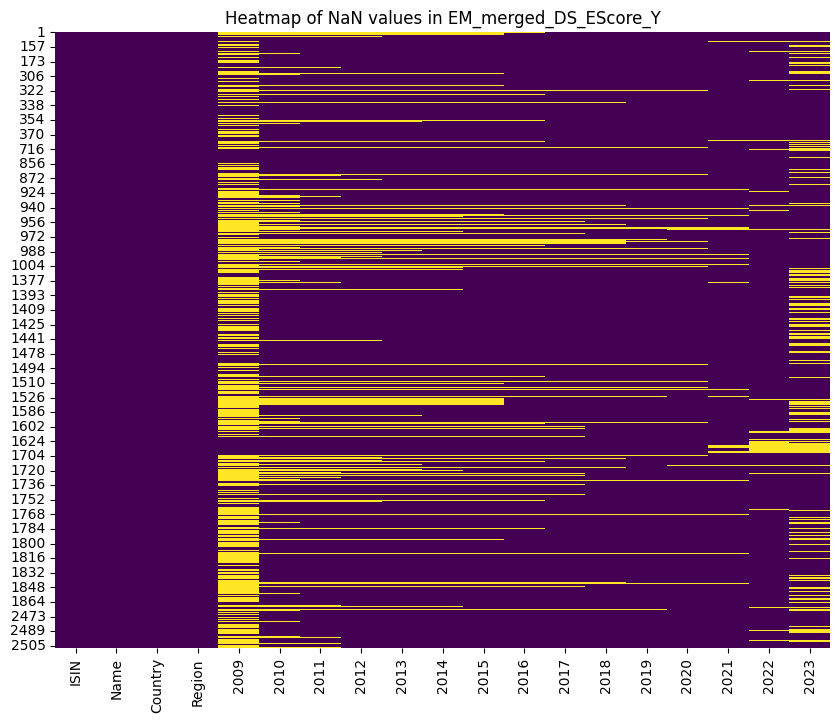

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(EM_merged_DS_EScore_Y.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of NaN values in EM_merged_DS_EScore_Y')
plt.show()

In [10]:
# Filling in missing ESG
df_filled = EM_merged_DS_EScore_Y.copy()

# Identify the year columns (assuming they are strings representing years)
year_columns = sorted([col for col in df_filled.columns if col.isdigit()])

# Iterate through the year columns
for i in range(1, len(year_columns)):
    prev_year = year_columns[i-1]
    current_year = year_columns[i]

    # Create a mask to select rows where:
    # 1. The current year is NaN
    # 2. The previous year is NOT NaN
    # 3. The previous year's value is a float
    mask = (df_filled[current_year].isna()) & \
           (df_filled[prev_year].notna()) & \
           (df_filled[prev_year].apply(lambda x: isinstance(x, (int, float)))) #check if int or float (not only float)

    # Fill the NaN values in the current year with the previous year's float value
    df_filled.loc[mask, current_year] = df_filled.loc[mask, prev_year]

# Update DS_ESGScore_Y_filtered with the filled values
EM_merged_DS_EScore_Y = df_filled

In [11]:
#FILTERING ONLY FIRMS WITH AN E SCORE FROM 2013 ON

# Remplacer les chaînes de caractères "NaN" par np.nan
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace('NaN', np.nan)
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y.replace(0, np.nan)

# Convert date columns to datetime if they are not already
date_columns = EM_merged_DS_EScore_Y.columns[4:]  # Assuming 'ISIN', 'Name', 'Country', 'Region' are the first 4 columns
EM_merged_DS_EScore_Y.columns = EM_merged_DS_EScore_Y.columns[:4].tolist() + pd.to_datetime(date_columns, errors='coerce').tolist()

# Select columns from 2013 onwards
start_date = pd.to_datetime('2013-12-31')
date_columns_2013_onwards = [col for col in EM_merged_DS_EScore_Y.columns
                             if isinstance(col, pd.Timestamp) and col >= start_date]

# Filter for rows with no NaN values in the selected columns
EM_merged_DS_EScore_Y = EM_merged_DS_EScore_Y[
    EM_merged_DS_EScore_Y[date_columns_2013_onwards].notna().all(axis=1)
]
EM_merged_DS_EScore_Y

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


#### Restricting RI to countries with E-Score

In [12]:
isin_list = EM_merged_DS_EScore_Y['ISIN'].tolist()

# Filter EM_merged_DS_R_USD_M to keep only rows with ISINs present in the list
filtered_EM_merged_DS_RI_USD_M = EM_merged_DS_RI_USD_M[EM_merged_DS_RI_USD_M['ISIN'].isin(isin_list)].copy()
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


In [13]:
rows_with_nans = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y.isnull().any(axis=1)]
nan_counts_per_row = rows_with_nans.isnull().sum(axis=1)
df_nan_rows = pd.DataFrame({'Row': rows_with_nans.index, 'Nan_Count': nan_counts_per_row})

df_nan_rows

,Row,Nan_Count
145,145,4
151,151,1
154,154,1
155,155,1
157,157,1
...,...,...
2502,2502,1
2503,2503,3
2505,2505,1
2506,2506,1


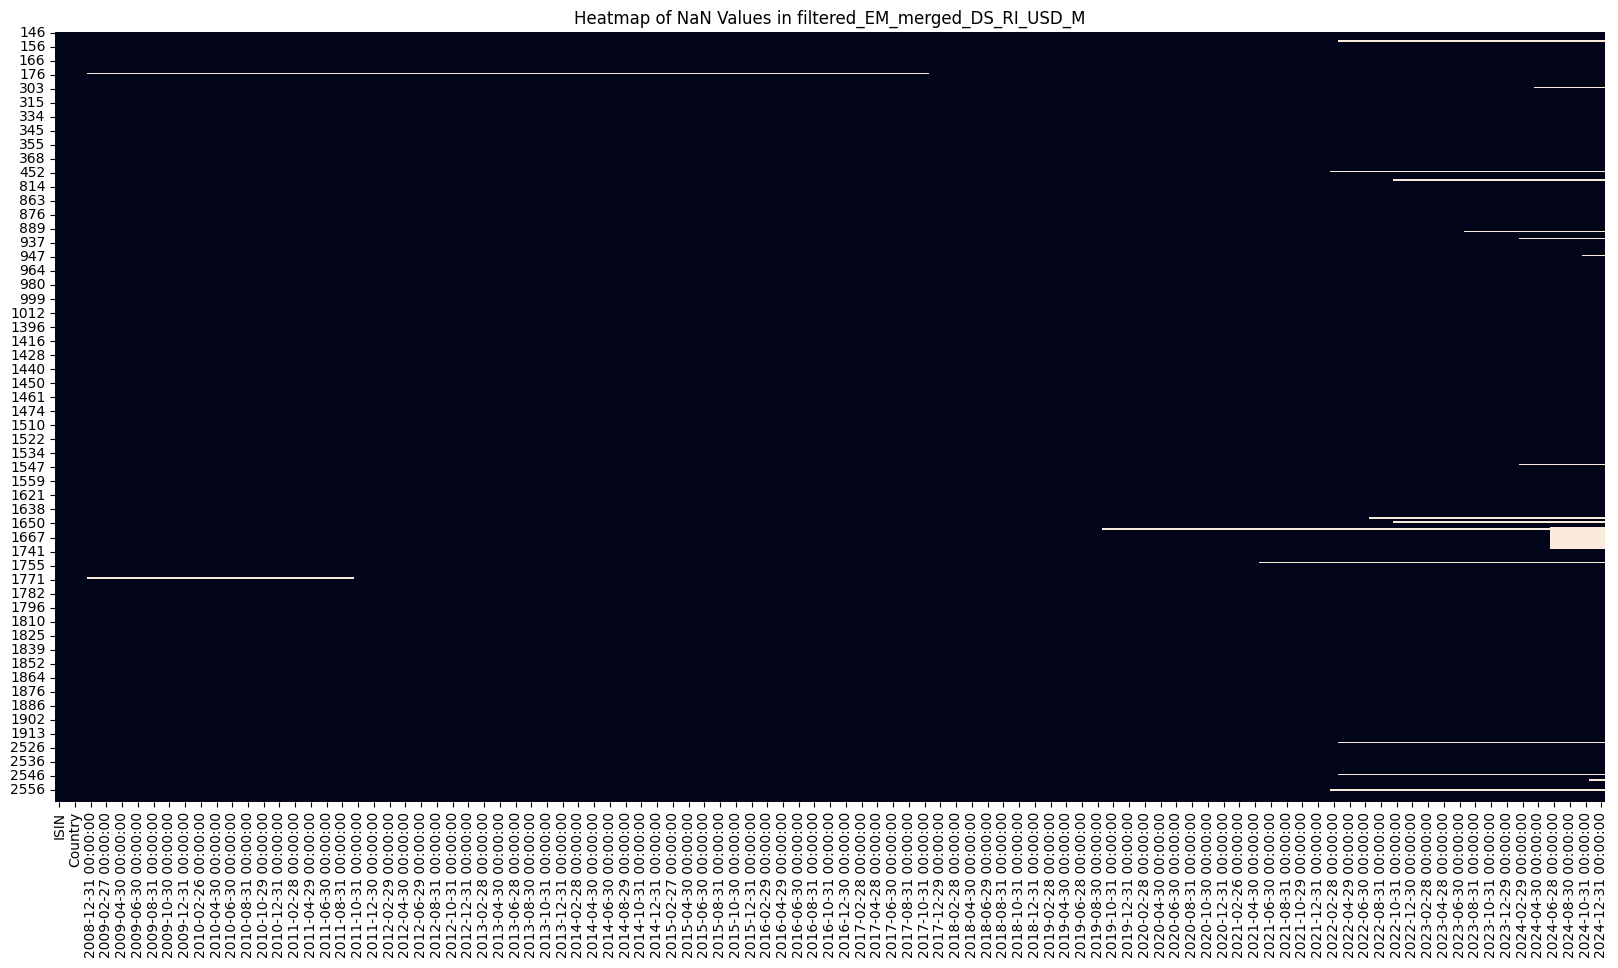

In [14]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()

#### HATZOLD RULE: NAN VALUES BETWEEN 2014 AND 2024

In [15]:
import pandas as pd
import numpy as np

# Make a copy to preserve the original
df_filled = filtered_EM_merged_DS_RI_USD_M.copy()

# Define time series columns (numerical columns across time)
time_cols = [col for col in df_filled.columns if col not in ['ISIN', 'Name', 'Country', 'Region']]

# Function to interpolate isolated NaNs across columns (i.e., along each row)
def interpolate_isolated_row(row):
    values = row.values.copy()
    for i in range(1, len(values) - 1):
        if pd.isna(values[i]) and not pd.isna(values[i - 1]) and not pd.isna(values[i + 1]):
            values[i] = (values[i - 1] + values[i + 1]) / 2
    return pd.Series(values, index=row.index)

# Apply row-wise interpolation only on the time columns
df_filled[time_cols] = df_filled[time_cols].apply(interpolate_isolated_row, axis=1)

# Optionally update the original DataFrame
filtered_EM_merged_DS_RI_USD_M = df_filled

In [16]:
filtered_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


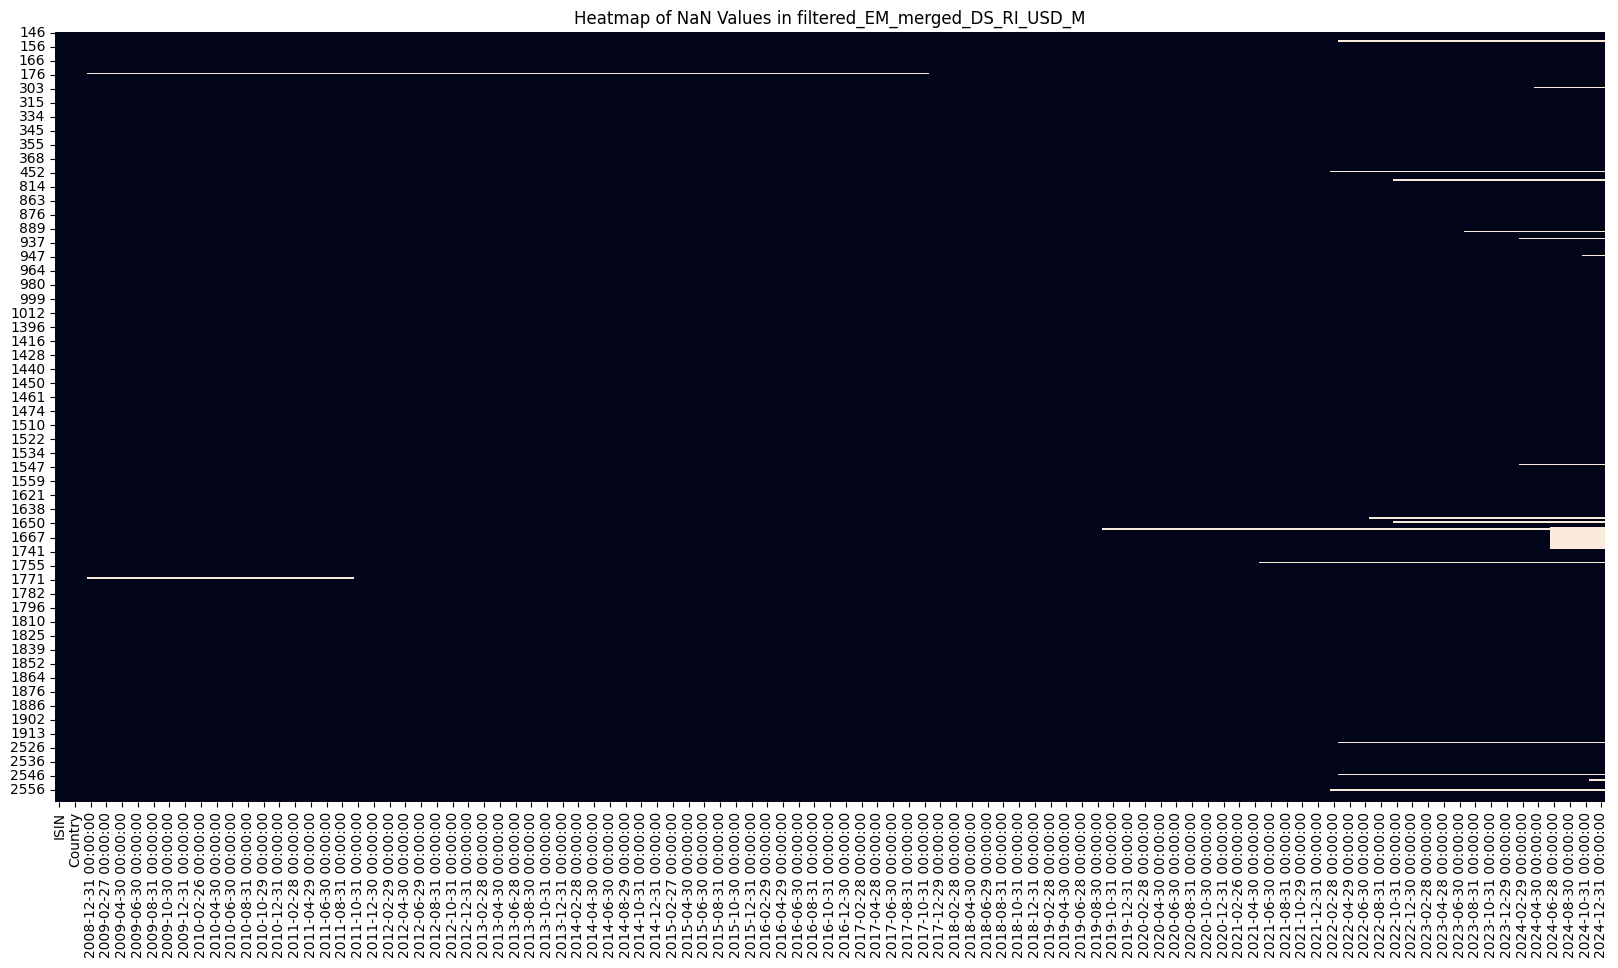

In [17]:
# prompt: can you create a heat map of nan in filtered_EM_merged_DS_RI_USD_M

plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_EM_merged_DS_RI_USD_M')
plt.show()


In the following part, we will first try to identify which firms to get rid of because of missing values ( time frame: 2004-2024: correct? )

In [18]:
# Filter for rows where 'Name' contains "SUSP" or "DELIST"
# Filter for rows where 'Name' contains "SUSP" or "DELIST" and select 'Name' and 'ISIN'
filtered_name_isin = filtered_EM_merged_DS_RI_USD_M[
    filtered_EM_merged_DS_RI_USD_M['Name'].str.contains("SUSP|DELIST", case=False, na=False)
][['Name', 'ISIN']]

filtered_name_isin

,Name,ISIN
152,CMPH.ENGT.DE SAOP.B PN DEAD - DELIST.29/03/22,BRCESPACNPB4
302,AES ANDES DEAD - DELIST.18/04/24,CL0002694637
378,TELF.O2 CZECH REPUBLIC DEAD - DELIST.25/02/22,CZ0009093209
722,LAMPRELL DEAD - DELIST.25/10/22,GB00B1CL5249
934,RELIANCE CAPITAL SUSP - SUSP.29/02/24,INE013A01015
946,IDFC DEAD - DELIST.11/10/24,INE043D01016
1544,UMW HOLDINGS DEAD - DELIST.19/02/24,MYL4588OO009
1646,GRUPA LOTOS DEAD - DELIST.12/08/22,PLLOTOS00025
1649,POLISH OIL AND GAS DEAD - DELIST.18/11/22,PLPGNIG00014
1753,THAI AIRWAYS INTL. SUSP - SUSP.25/03/24,TH0245010002


In [19]:
isins_to_remove = filtered_name_isin['ISIN'].tolist()

filtered_dead_EM_merged_DS_RI_USD_M = filtered_EM_merged_DS_RI_USD_M[~filtered_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)]

filtered_dead_EM_merged_DS_RI_USD_M

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
146,BRABEVACNOR1,AMBEV ON,BR,EM,394.23,377.41,385.15,439.05,499.37,600.61,...,1199.78,1127.14,1057.57,987.73,985.01,1091.85,1154.89,1049.92,1025.18,963.62
147,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,245.54,238.41,232.53,295.41,343.13,434.93,...,1272.70,1190.47,1161.15,1109.30,1083.48,1164.81,1178.58,1074.08,998.11,947.95
148,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,1045.32,969.65,946.95,1094.17,1366.23,1686.93,...,1893.69,1797.94,1607.05,1495.68,1489.17,1884.13,1854.74,1719.88,1477.92,1316.83
149,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,1499.44,1619.46,1465.67,1468.26,1748.31,2339.82,...,902.28,901.27,978.31,1129.50,1031.04,1281.75,1201.84,1253.98,1177.39,1168.17
150,BRBRKMACNPA4,BRASKEM PN A,BR,EM,130.15,134.40,123.86,114.25,155.57,198.78,...,497.04,386.92,338.89,303.03,292.59,300.20,344.89,285.88,236.76,176.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ZAE000191342,ALTRON LIMITED A,ZA,EM,118.52,113.91,93.10,102.74,126.74,139.73,...,103.80,108.05,121.84,131.64,173.36,175.55,184.07,190.50,209.13,210.60
2561,ZAE000255915,ABSA GROUP,ZA,EM,229.96,179.19,174.18,206.75,237.39,258.24,...,373.17,386.72,396.75,434.53,439.89,495.99,531.01,497.48,498.09,524.49
2562,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,16.97,13.06,16.55,20.93,25.86,32.95,...,53.35,59.43,61.64,62.37,70.16,53.12,56.97,66.32,56.06,46.48
2563,ZAE000302618,AVENG,ZA,EM,68.95,53.69,53.19,56.84,80.05,90.09,...,0.05,0.05,0.05,0.06,0.08,0.09,0.09,0.08,0.10,0.10


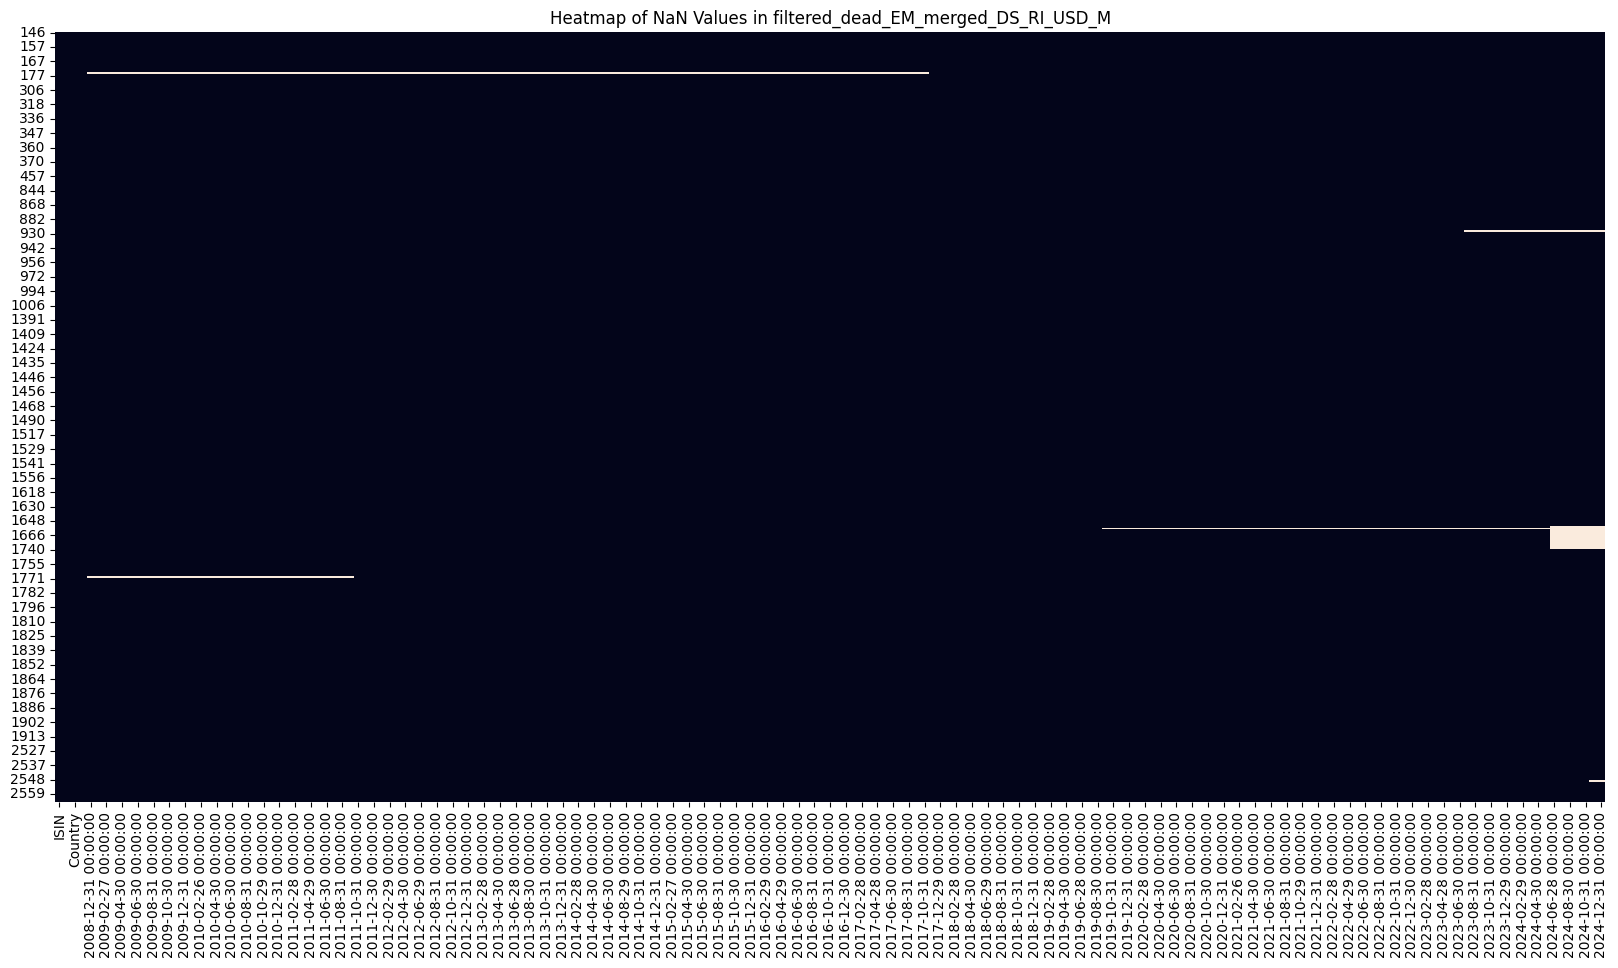

In [20]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_EM_merged_DS_RI_USD_M')
plt.show()

In [21]:
df_nan_rows = filtered_dead_EM_merged_DS_RI_USD_M[filtered_dead_EM_merged_DS_RI_USD_M.isnull().any(axis=1)][['Name', 'ISIN']]
df_nan_rows

,Name,ISIN
175,SUZANO ON,BRSUZBACNOR0
928,HOUSING DEVELOPMENT FINANCE CORPORATION,INE001A01036
1660,MMC NORILSK NICKEL,RU0007288411
1661,URALKALI,RU0007661302
1662,GAZPROM,RU0007661625
1663,ROSTELECOM,RU0008943394
1664,NK LUKOIL,RU0009024277
1665,SBERBANK OF RUSSIA,RU0009029540
1666,TATNEFT,RU0009033591
1667,SEVERSTAL,RU0009046510


In [22]:
isins_to_remove = df_nan_rows['ISIN'].tolist()

# Remove rows where ISIN is in isins_to_remove
filtered_dead_nan_EM_merged_DS_RI_USD_M = filtered_dead_EM_merged_DS_RI_USD_M[
    ~filtered_dead_EM_merged_DS_RI_USD_M['ISIN'].isin(isins_to_remove)
]

In [23]:
nan_counts = filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull().sum().sum()
print("Total number of NaN values:", nan_counts)

Total number of NaN values: 0


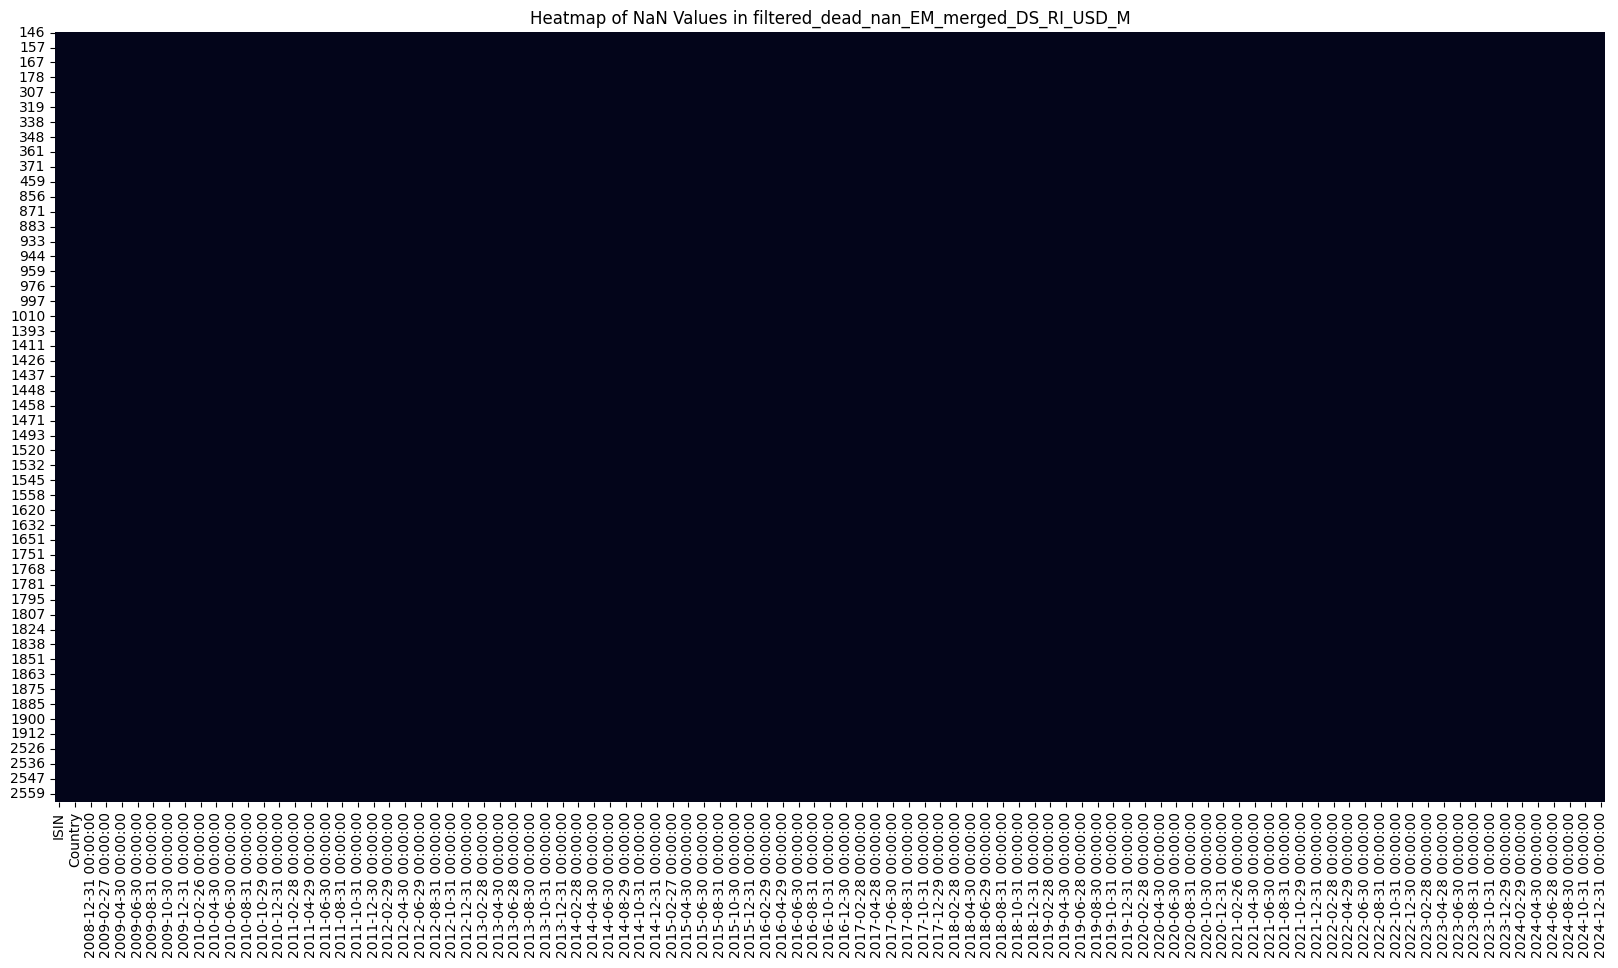

In [24]:
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(filtered_dead_nan_EM_merged_DS_RI_USD_M.isnull(), cbar=False)
plt.title('Heatmap of NaN Values in filtered_dead_nan_EM_merged_DS_RI_USD_M')
plt.show()

## Data frames

### Return index dataframe

In [25]:
returns = filtered_dead_nan_EM_merged_DS_RI_USD_M

### Simple returns data frame

In [26]:
# 1. Define metadata columns
metadata_cols = ['ISIN', 'Name', 'Country', 'Region']

# 2. Separate date and metadata columns
date_cols = [col for col in returns.columns if col not in metadata_cols]

# 3. Convert date columns to numeric (coerce errors)
data = returns[date_cols].apply(pd.to_numeric, errors='coerce')

# 4. Compute simple returns using built-in pct_change
returns_pct = data.pct_change(axis=1)

# 5. Replace infinite values and fill NaNs with 0
returns_pct.replace([np.inf, -np.inf], 0, inplace=True)
returns_pct.fillna(0, inplace=True)

# 6. Combine with metadata
simple_returns = pd.concat([
    returns[metadata_cols].reset_index(drop=True),
    returns_pct.reset_index(drop=True)
], axis=1)

simple_returns

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


### E-Score data frame

In [27]:
isin_list_R = simple_returns['ISIN'].tolist()

# Filter EM_merged_DS_EScore_Y to keep only rows with ISINs present in the list
EScore = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_R)].copy()

EScore

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


### Market cap data frame

In [28]:
filtered_EM_DS_MV_USD_M = DS_MV_USD_M[DS_MV_USD_M['ISIN'].isin(isin_list_R)].copy()
market_cap_M = filtered_EM_DS_MV_USD_M

In [29]:
filtered_EM_DS_MV_USD_Y = DS_MV_USD_Y[DS_MV_USD_Y['ISIN'].isin(isin_list_R)].copy()
market_cap_Y = filtered_EM_DS_MV_USD_Y

### Risk free rate data frame

In [30]:
df = Risk_Free_Rate.copy()

df[df.columns[0]] = df[df.columns[0]].astype(str)

# Extract year (first 4 characters) and month (characters 5-6)
df['Year'] = df.iloc[:, 0].str[:4].astype(int)
df['Month'] = df.iloc[:, 0].str[4:6].astype(int)  # Extract month

# Get the last day of the month using calendar.monthrange
df['LastDay'] = df.apply(lambda row: calendar.monthrange(row['Year'], row['Month'])[1], axis=1)
# Rename 'LastDay' to 'Day' for pd.to_datetime
df = df.rename(columns={'LastDay': 'Day'}) # Rename to 'Day' to match expected input for pd.to_datetime

# Now create the 'ReadableDate' column using the calculated LastDay
df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']]) # Use 'Day' instead of 'LastDay'

# Drop the temporary 'Year', 'Month', and 'Day' columns
df = df.drop(['Year', 'Month', 'Day', 'Unnamed: 0' ], axis=1)

df = df[['date', 'RF']]

df['date'] = pd.to_datetime(df['date'])
df['RF'] = df['RF'] / 100

#df["RF"] = (1 + df["RF"]) ** (1/12) - 1
#df['RF'] = df['RF'] / 12

risk_free_rate = df

### Simple returns no zeros

In [31]:
threshold = 0.40

def remove_rows_with_many_zeros(df, threshold):
  """Removes rows where the count of zero values exceeds the threshold."""
  rows_to_drop = []
  for index, row in df.iterrows():
    total_values = len(row)
    zero_count = (row == 0).sum()
    if total_values > 0 and (zero_count / total_values) > threshold:
      rows_to_drop.append(index)

  df_cleaned = df.drop(rows_to_drop)
  return df_cleaned

# Example usage:
simple_returns_cleaned = remove_rows_with_many_zeros(simple_returns, threshold)

# Print the cleaned DataFrame
simple_returns_no_zeros = simple_returns_cleaned

isin_list_simple_returns_cleaned = simple_returns_no_zeros['ISIN'].tolist()

In [32]:
simple_returns_no_zeros

,ISIN,Name,Country,Region,2008-12-31 00:00:00,2009-01-30 00:00:00,2009-02-27 00:00:00,2009-03-31 00:00:00,2009-04-30 00:00:00,2009-05-29 00:00:00,...,2024-03-29 00:00:00,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00
0,BRABEVACNOR1,AMBEV ON,BR,EM,0.0,-0.042665,0.020508,0.139945,0.137388,0.202735,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
1,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,0.0,-0.029038,-0.024663,0.270417,0.161538,0.267537,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
2,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,0.0,-0.072389,-0.023411,0.155468,0.248645,0.234734,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
3,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,0.0,0.080043,-0.094964,0.001767,0.190736,0.338332,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
4,BRBRKMACNPA4,BRASKEM PN A,BR,EM,0.0,0.032655,-0.078423,-0.077588,0.361663,0.277753,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
511,ZAE000191342,ALTRON LIMITED A,ZA,EM,0.0,-0.038896,-0.182688,0.103545,0.233599,0.102493,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
512,ZAE000255915,ABSA GROUP,ZA,EM,0.0,-0.220778,-0.027959,0.186990,0.148198,0.087830,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
513,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,0.0,-0.230407,0.267228,0.264653,0.235547,0.274169,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888
514,ZAE000302618,AVENG,ZA,EM,0.0,-0.221320,-0.009313,0.068622,0.408339,0.125422,...,-0.166667,0.000000,0.000000,0.200000,0.333333,0.125000,0.000000,-0.111111,0.250000,0.000000


In [33]:
nan_count = simple_returns_no_zeros.isnull().sum().sum()
print(f"Total number of NaN values in simple_returns_no_zeros: {nan_count}")

Total number of NaN values in simple_returns_no_zeros: 0


<ipython-input-34-40a93cce14bd>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(simple_returns_no_zeros.iloc[:, 4:].applymap(lambda x: 1 if x == 0 else 0), cmap='viridis', cbar=False)


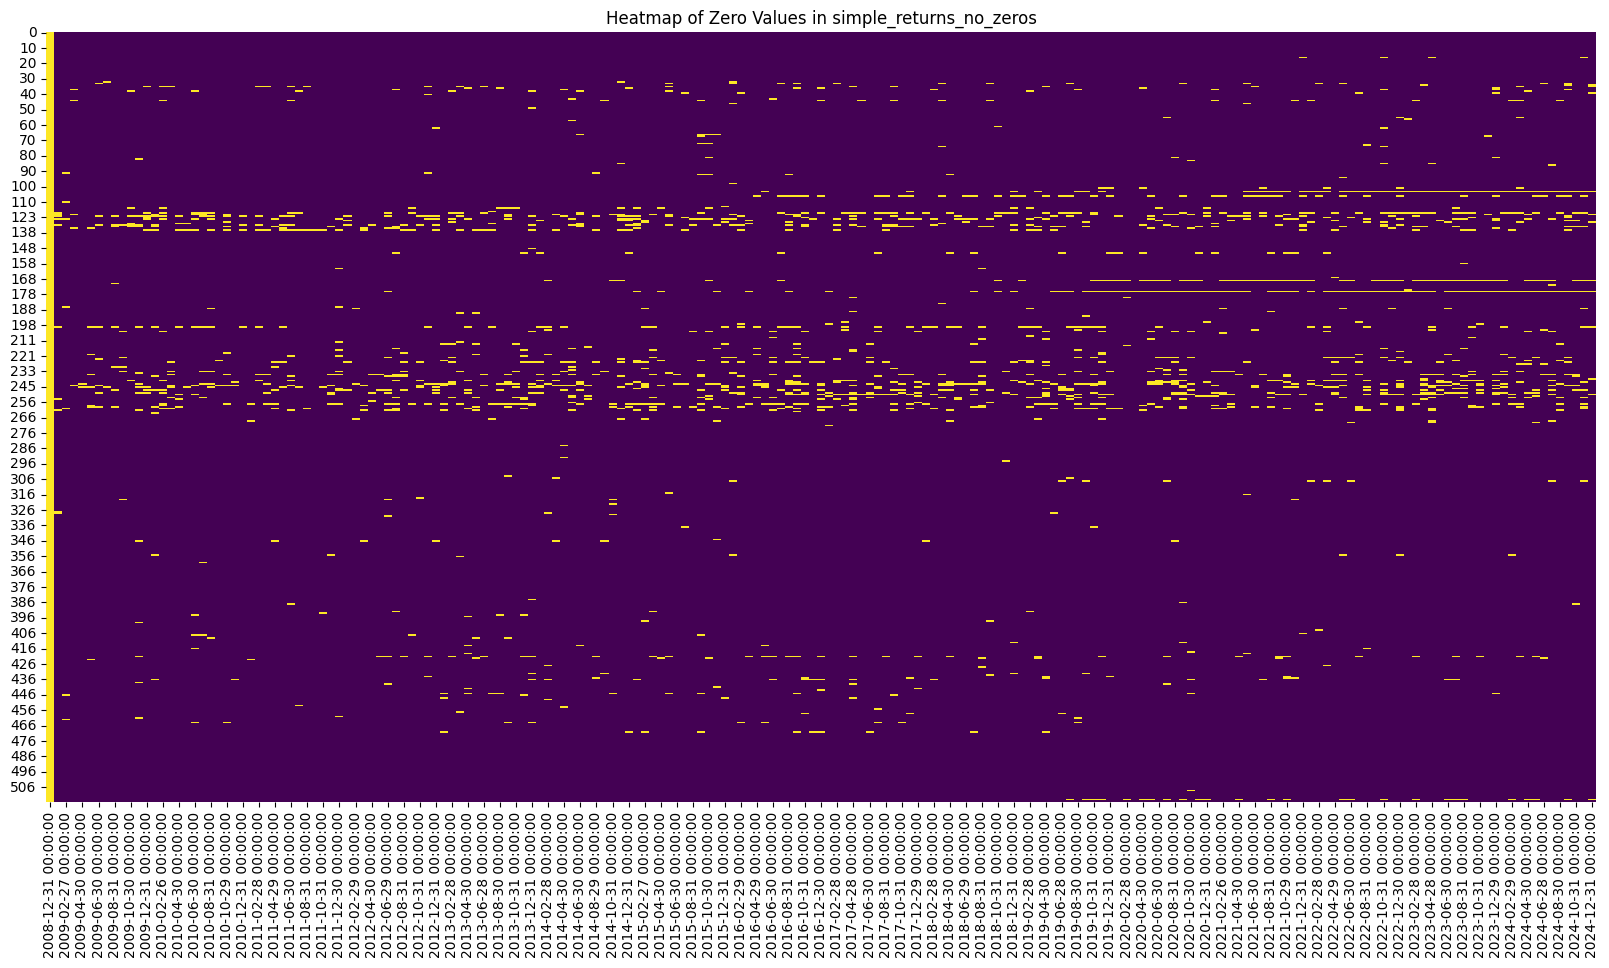

In [34]:
plt.figure(figsize=(20, 10))
sns.heatmap(simple_returns_no_zeros.iloc[:, 4:].applymap(lambda x: 1 if x == 0 else 0), cmap='viridis', cbar=False)
plt.title('Heatmap of Zero Values in simple_returns_no_zeros')
plt.show()

### E-Score no zeros

In [35]:
EScore_no_zeros = EM_merged_DS_EScore_Y[EM_merged_DS_EScore_Y['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
EScore_no_zeros

,ISIN,Name,Country,Region,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
145,BRABEVACNOR1,AMBEV ON,BR,EM,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
146,BRBBASACNOR3,BANCO DO BRASIL ON,BR,EM,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
147,BRBBDCACNPR8,BANCO BRADESCO PN,BR,EM,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
148,BRBRFSACNOR8,BRF BRASIL FOODS ON,BR,EM,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
149,BRBRKMACNPA4,BRASKEM PN A,BR,EM,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2503,ZAE000191342,ALTRON LIMITED A,ZA,EM,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
2504,ZAE000255915,ABSA GROUP,ZA,EM,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
2505,ZAE000298253,NORTHAM PLATINUM HLDGS,ZA,EM,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96
2506,ZAE000302618,AVENG,ZA,EM,NaN,58.89,62.27,78.98,72.99,64.66,69.09,70.85,52.33,45.73,44.32,44.52,48.95,31.21,25.61


### Market Cap no zeros

In [36]:
market_cap_M_no_zeros = DS_MV_USD_M[DS_MV_USD_M['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
market_cap_M_no_zeros

,NAME,ISIN,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,...,2024-04-30 00:00:00,2024-05-31 00:00:00,2024-06-28 00:00:00,2024-07-31 00:00:00,2024-08-30 00:00:00,2024-09-30 00:00:00,2024-10-31 00:00:00,2024-11-29 00:00:00,2024-12-31 00:00:00,2025-01-31 00:00:00
146,AMBEV ON,BRABEVACNOR1,898.33,848.69,810.12,1064.46,1062.92,1017.51,1287.05,1591.09,...,36938.22,34658.22,32369.65,32280.60,35781.82,37847.65,34407.58,33596.80,29944.81,29942.67
147,BANCO DO BRASIL ON,BRBBASACNOR3,1869.6,1744.22,1680.67,1438.89,1327.29,1246.41,1427.23,1404.38,...,30317.50,29570.88,27558.30,26916.82,28455.29,28602.67,26066.58,23775.07,22421.07,27155.61
148,BANCO BRADESCO PN,BRBBDCACNPR8,4233.93,4330.41,3849.25,4416.12,3920.07,3616.62,4663.78,4660.55,...,14347.73,12805.03,11839.36,11680.45,14669.45,14338.50,13186.18,11236.44,9939.55,10993.84
149,BRF BRASIL FOODS ON,BRBRFSACNOR8,168.22,126.22,126.78,128.56,124.32,126.71,127.79,113.22,...,5479.35,5947.72,6866.89,6268.28,7792.49,7306.66,7623.63,6991.22,6906.52,6304.78
150,BRASKEM PN A,BRBRKMACNPA4,378.1,382.60,389.65,390.56,382.71,373.34,422.45,509.39,...,1416.69,1240.83,1109.52,1071.31,1099.16,1262.82,1046.73,866.89,646.79,815.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ALTRON LIMITED A,ZAE000191342,105.41,115.91,106.13,113.98,90.17,76.58,74.37,85.52,...,248.89,280.70,295.36,388.98,393.90,413.00,427.45,460.04,463.34,472.18
2561,ABSA GROUP,ZAE000255915,2882.25,2649.35,2483.04,2348.10,2295.91,2374.43,2458.35,2347.50,...,6906.91,7086.12,7760.90,7856.60,8858.64,9105.44,8530.48,8540.85,8993.55,8893.95
2562,NORTHAM PLATINUM HLDGS,ZAE000298253,230.57,259.71,207.52,249.66,193.50,206.19,264.77,300.82,...,2632.31,2730.05,2762.38,3107.39,2352.88,2507.23,2918.45,2467.31,2045.45,2687.92
2563,AVENG,ZAE000302618,436.66,445.83,454.09,389.04,351.95,276.11,312.53,299.24,...,42.32,39.84,48.32,61.15,71.10,70.09,66.52,78.76,84.89,83.96


In [37]:
market_cap_Y_no_zeros = DS_MV_USD_Y[DS_MV_USD_Y['ISIN'].isin(isin_list_simple_returns_cleaned)].copy()
market_cap_Y_no_zeros

,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
146,AMBEV ON,BRABEVACNOR1,NaN,819.89,3937.94,2602.40,1896.76,3559.93,11591.19,12592.77,...,99515.76,69538.70,90471.62,107508.68,77276.64,56712.12,39584.64,46420.10,40387.05,41249.56
147,BANCO DO BRASIL ON,BRBBASACNOR3,1229.28,1699.83,1491.64,1777.86,1936.54,5436.48,9889.44,20860.01,...,22818.99,9491.81,30601.78,38066.35,39989.52,29529.50,14422.12,19569.90,22329.53,33330.86
148,BANCO BRADESCO PN,BRBBDCACNPR8,1985.4,4140.79,4189.36,4149.60,2015.24,3825.63,7645.06,20084.50,...,27716.97,13100.56,29942.02,38172.77,40138.61,27651.57,18303.76,19138.44,13621.42,14719.11
149,BRF BRASIL FOODS ON,BRBRFSACNOR8,48.47,126.53,114.56,96.60,69.13,147.38,293.92,579.23,...,20231.08,10194.51,10648.29,7175.60,4725.59,5266.64,3154.82,3508.56,1346.17,4733.06
150,BRASKEM PN A,BRBRKMACNPA4,90.45,386.95,352.75,243.08,98.96,1220.00,3031.10,2055.91,...,1588.06,2159.27,3598.81,5028.61,5139.27,2269.71,1935.44,3194.64,1319.91,1446.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2560,ALTRON LIMITED A,ZAE000191342,94.56,107.67,99.15,64.30,100.20,168.36,266.46,404.40,...,164.32,29.98,81.55,438.82,534.90,527.84,305.93,201.56,186.80,206.59
2561,ABSA GROUP,ZAE000255915,2769.41,2538.47,2643.38,1648.06,2716.00,4536.54,8868.79,12924.62,...,14339.19,7622.05,10219.45,14896.64,11171.05,8074.78,6791.52,9884.60,9004.67,7674.69
2562,NORTHAM PLATINUM HLDGS,ZAE000298253,129.22,211.66,457.28,312.74,451.25,376.75,351.63,1032.35,...,1727.00,1049.09,1987.98,1878.19,2067.38,4399.06,7468.55,5917.59,3332.08,2267.72
2563,AVENG,ZAE000302618,NaN,460.16,397.60,257.32,465.76,462.54,801.12,1509.59,...,562.52,77.34,231.85,61.56,41.90,25.62,78.03,164.93,106.15,47.52


# Data frames restricted time frame

### Simple returns no zeros

In [38]:
df = simple_returns_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:3]) + list(pd.to_datetime(df.columns[3:]))

start_date = pd.to_datetime('2009-01-30 00:00:00')
end_date = pd.to_datetime('2024-12-31 00:00:00')

# Select only the date range columns
simple_returns_M_2009_2024 = df.loc[:, start_date:end_date]

simple_returns_M_2009_2024

,2009-01-30,2009-02-27,2009-03-31,2009-04-30,2009-05-29,2009-06-30,2009-07-31,2009-08-31,2009-09-30,2009-10-30,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,-0.042665,0.020508,0.139945,0.137388,0.202735,-0.015351,0.071526,0.127902,0.112810,0.082226,...,-0.014473,-0.060544,-0.061723,-0.066038,-0.002754,0.108466,0.057737,-0.090892,-0.023564,-0.060048
BRBBASACNOR3,-0.029038,-0.024663,0.270417,0.161538,0.267537,0.015014,0.165587,0.118995,0.260807,-0.077842,...,-0.021737,-0.064611,-0.024629,-0.044654,-0.023276,0.075064,0.011822,-0.088666,-0.070730,-0.050255
BRBBDCACNPR8,-0.072389,-0.023411,0.155468,0.248645,0.234734,-0.036107,0.067797,0.046571,0.205743,0.002816,...,0.030787,-0.050563,-0.106172,-0.069301,-0.004353,0.265222,-0.015599,-0.072711,-0.140684,-0.108998
BRBRFSACNOR8,0.080043,-0.094964,0.001767,0.190736,0.338332,-0.038486,0.152918,0.018109,0.179561,-0.076438,...,0.072827,-0.001119,0.085479,0.154542,-0.087171,0.243162,-0.062344,0.043383,-0.061078,-0.007831
BRBRKMACNPA4,0.032655,-0.078423,-0.077588,0.361663,0.277753,0.007898,0.208685,0.263173,0.129916,0.060759,...,0.245496,-0.221552,-0.124134,-0.105816,-0.034452,0.026009,0.148867,-0.171098,-0.171820,-0.253886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,-0.038896,-0.182688,0.103545,0.233599,0.102493,0.190152,0.065484,0.002709,0.024090,0.047046,...,0.082942,0.040944,0.127626,0.080433,0.316925,0.012633,0.048533,0.034932,0.097795,0.007029
ZAE000255915,-0.220778,-0.027959,0.186990,0.148198,0.087830,0.127362,0.052348,0.105134,-0.026847,0.004522,...,-0.082512,0.036311,0.025936,0.095224,0.012335,0.127532,0.070606,-0.063144,0.001226,0.053002
ZAE000298253,-0.230407,0.267228,0.264653,0.235547,0.274169,-0.087102,0.218085,0.087063,-0.144615,0.088641,...,0.052891,0.113964,0.037187,0.011843,0.124900,-0.242873,0.072477,0.164121,-0.154704,-0.170888


### Market cap no zeros

In [39]:
df = market_cap_Y_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:2]) + list(pd.to_datetime(df.columns[2:]))

start_date = pd.to_datetime('2009')
end_date = pd.to_datetime('2024')

# Select only the date range columns
market_cap_Y_2009_2024 = df.loc[:, start_date:end_date]

market_cap_Y_2009_2024

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00,2024-01-01 00:00:00
ISIN,,,,,,,,,,,,,,,,
BRABEVACNOR1,12459.26,28572.71,38352.47,58002.65,77661.18,112045.24,99515.76,69538.70,90471.62,107508.68,77276.64,56712.12,39584.64,46420.10,40387.05,41249.56
BRBBASACNOR3,15311.83,42291.45,50279.94,45935.40,36647.03,23818.34,22818.99,9491.81,30601.78,38066.35,39989.52,29529.50,14422.12,19569.90,22329.53,33330.86
BRBBDCACNPR8,13831.15,29506.49,36054.97,34042.85,33523.21,23987.44,27716.97,13100.56,29942.02,38172.77,40138.61,27651.57,18303.76,19138.44,13621.42,14719.11
BRBRFSACNOR8,2592.31,10634.70,15061.16,17852.74,18677.98,14895.12,20231.08,10194.51,10648.29,7175.60,4725.59,5266.64,3154.82,3508.56,1346.17,4733.06
BRBRKMACNPA4,734.86,2330.45,4210.54,3182.58,2547.68,2433.94,1588.06,2159.27,3598.81,5028.61,5139.27,2269.71,1935.44,3194.64,1319.91,1446.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,212.03,358.46,391.78,331.51,260.48,236.45,164.32,29.98,81.55,438.82,534.90,527.84,305.93,201.56,186.80,206.59
ZAE000255915,6498.75,12444.13,13278.42,15056.44,13286.88,10409.74,14339.19,7622.05,10219.45,14896.64,11171.05,8074.78,6791.52,9884.60,9004.67,7674.69
ZAE000298253,833.24,2094.32,2543.85,1687.29,1695.81,1502.48,1727.00,1049.09,1987.98,1878.19,2067.38,4399.06,7468.55,5917.59,3332.08,2267.72


### E-Score no zeros

In [40]:
df = EScore_no_zeros.copy()

# Ensure the ISIN column is included and set as the index
df.set_index("ISIN", inplace=True)

# Convert date columns to datetime format
df.columns = list(df.columns[:4]) + list(pd.to_datetime(df.columns[4:]))

start_date = pd.to_datetime('2009')
end_date = pd.to_datetime('2023')

# Select only the date range columns
EScore_Y_2009_2024 = df.loc[:, start_date:end_date]

EScore_Y_2009_2024

,2009-01-01 00:00:00,2010-01-01 00:00:00,2011-01-01 00:00:00,2012-01-01 00:00:00,2013-01-01 00:00:00,2014-01-01 00:00:00,2015-01-01 00:00:00,2016-01-01 00:00:00,2017-01-01 00:00:00,2018-01-01 00:00:00,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-01-01 00:00:00
ISIN,,,,,,,,,,,,,,,
BRABEVACNOR1,NaN,NaN,NaN,NaN,57.38,58.81,66.63,74.17,67.08,55.27,68.85,72.11,77.48,67.51,62.78
BRBBASACNOR3,68.98,87.93,85.72,87.23,89.93,90.21,91.78,94.54,94.64,94.43,94.44,91.44,91.20,92.86,93.30
BRBBDCACNPR8,78.70,84.85,86.45,81.49,80.31,83.16,88.79,95.72,96.06,96.32,95.57,94.90,95.52,94.60,97.80
BRBRFSACNOR8,53.61,42.42,65.34,77.78,75.80,78.70,75.73,77.90,77.55,77.98,72.71,77.44,81.78,82.94,82.34
BRBRKMACNPA4,58.64,58.57,61.40,57.79,57.57,41.05,44.03,43.06,50.40,53.56,49.96,50.09,51.08,48.23,50.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,NaN,NaN,NaN,43.78,44.42,54.31,56.78,59.55,57.53,30.93,30.08,27.51,38.62,31.87,37.06
ZAE000255915,52.20,53.90,48.96,58.02,56.43,55.56,68.94,75.90,81.90,80.63,83.03,81.99,81.45,79.12,84.75
ZAE000298253,NaN,60.96,53.53,59.07,54.34,54.03,52.42,56.64,53.90,63.37,62.03,67.79,73.50,74.37,63.96


# Question 4: Daniel

In [41]:
# === Replace with your actual DataFrames ===
market_cap_df = market_cap_Y_2009_2024
EScore_df = EScore_Y_2009_2024
returns_df = simple_returns_M_2009_2024

market_cap_df.columns = pd.to_datetime(market_cap_df.columns).year.astype(str)
EScore_df.columns = pd.to_datetime(EScore_df.columns).year.astype(str)

returns_df.columns = pd.to_datetime(returns_df.columns)

# === Store results ===
optimized_weights_by_year = {}
benchmark_scores = {}
optimized_scores = {}

# === Loop through years ===
for year in range(2013, 2024):
    print(f"Processing year: {year}")

    try:
        # --- Extract benchmark inputs ---
        market_caps = market_cap_df[str(year)]
        ESG_scores = EScore_df[str(year)]

        # Drop missing firms
        valid_firms = market_caps.dropna().index.intersection(ESG_scores.dropna().index)
        market_caps = market_caps.loc[valid_firms]
        ESG_scores = ESG_scores.loc[valid_firms]

        alpha_vw = market_caps / market_caps.sum()  # benchmark weights
        Sc_vw = np.dot(alpha_vw, ESG_scores)        # benchmark ESG score

        # --- Covariance matrix  ---

        #mask = returns_df.columns.to_series().dt.year == year + 0
        mask = returns_df.columns.to_series().dt.year.isin([year -4, year -3, year -2, year-1, year])
        returns_year = returns_df.loc[valid_firms, mask]

        Sigma = returns_year.T.cov().values  # Covariance matrix

        n_assets = len(alpha_vw)

        # --- Optimization setup ---
        def tracking_error_variance(alpha, alpha_vw, Sigma):
            diff = alpha - alpha_vw
            return diff.T @ Sigma @ diff

        constraint_sum = {'type': 'eq', 'fun': lambda alpha: np.sum(alpha) - 1}
        constraint_esg = {
            'type': 'ineq',
            'fun': lambda alpha: np.dot(alpha, ESG_scores.values) - 1.2 * Sc_vw
        }
        bounds = [(0, 1) for _ in range(n_assets)]
        constraints = [constraint_sum, constraint_esg]

        x0 = alpha_vw.values

        # --- Run optimizer ---
        result = minimize(
            tracking_error_variance,
            x0=x0,
            args=(alpha_vw.values, Sigma),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )

        if result.success:
            optimized_weights = pd.Series(result.x, index=valid_firms)
            optimized_weights_by_year[year] = optimized_weights

            # Store ESG scores
            benchmark_scores[year] = Sc_vw
            optimized_scores[year] = np.dot(result.x, ESG_scores.values)

        else:
            print(f"Optimization failed for year {year}: {result.message}")

    except Exception as e:
        print(f"Error in year {year}: {e}")

Processing year: 2013
Processing year: 2014
Processing year: 2015
Processing year: 2016
Processing year: 2017
Processing year: 2018
Processing year: 2019
Processing year: 2020
Processing year: 2021
Processing year: 2022
Processing year: 2023


In [42]:
returns_year

,2019-01-31,2019-02-28,2019-03-29,2019-04-30,2019-05-31,2019-06-28,2019-07-31,2019-08-30,2019-09-30,2019-10-31,...,2023-03-31,2023-04-28,2023-05-31,2023-06-30,2023-07-31,2023-08-31,2023-09-29,2023-10-31,2023-11-30,2023-12-29
ISIN,,,,,,,,,,,,,,,,,,,,,
BRABEVACNOR1,0.211283,-0.044187,-0.058715,0.081172,-0.041091,0.041111,0.146163,-0.153229,0.020111,-0.063179,...,0.101956,0.001449,-0.005997,0.135437,-0.022119,-0.105117,-0.063018,-0.026424,0.088450,0.072456
BRBBASACNOR3,0.186834,-0.041690,-0.069433,0.004583,0.062208,0.065971,-0.070515,-0.136395,-0.019323,0.098287,...,0.008647,0.110643,0.016871,0.204186,-0.010760,-0.044926,-0.002162,0.017115,0.165437,0.043083
BRBBDCACNPR8,0.246496,-0.071001,-0.043283,-0.019979,0.049954,0.043019,-0.066690,-0.128180,0.023626,0.079586,...,0.045634,0.073888,0.101966,0.132150,0.033372,-0.131433,-0.047094,-0.021549,0.197642,0.071529
BRBRFSACNOR8,0.142056,-0.151209,0.061102,0.350535,-0.099708,0.088435,0.152844,0.039467,-0.006415,-0.035453,...,0.038036,0.034695,0.252516,0.163635,0.110809,-0.110041,0.114979,0.039261,0.404796,-0.043499
BRBRKMACNPA4,0.173523,0.011123,-0.098346,-0.075212,-0.096437,-0.163688,-0.010181,-0.245118,0.143168,-0.091355,...,-0.009224,0.035988,0.108533,0.317048,-0.075477,-0.158688,-0.087353,-0.222720,0.217142,0.160265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,0.059965,0.008082,0.021693,0.051812,0.199890,0.111914,0.044733,-0.202755,0.068220,0.003420,...,0.030978,-0.010382,-0.251543,0.185851,0.021416,0.054323,-0.044938,0.072742,0.163600,0.083839
ZAE000255915,0.237905,-0.077601,-0.178891,0.128140,0.013204,0.075110,-0.097365,-0.101538,0.027751,0.019808,...,-0.052316,-0.016696,-0.201014,0.144995,0.198544,-0.096308,0.002105,-0.023289,0.011633,-0.023707
ZAE000298253,0.210736,0.079803,0.119830,-0.055948,-0.069620,0.081942,0.062589,0.164874,0.058416,0.235166,...,-0.009869,0.200235,-0.163532,-0.189079,0.279258,-0.226179,-0.017643,-0.015368,0.069951,0.195958


In [43]:
# Combine optimized weights into one DataFrame
optimized_weights_df = pd.DataFrame(optimized_weights_by_year)

# ESG scores comparison
score_comparison = pd.DataFrame({
    'benchmark_ESG': benchmark_scores,
    'optimized_ESG': optimized_scores
})

In [44]:
optimized_weights_df

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
ISIN,,,,,,,,,,,
BRABEVACNOR1,1.633044e-02,2.514562e-02,1.982574e-02,1.883908e-02,1.766197e-02,1.150000e-02,9.203541e-03,4.436972e-03,6.395872e-05,0.000000e+00,6.673722e-19
BRBBASACNOR3,9.254320e-03,6.691790e-03,5.611270e-03,3.528095e-03,9.531430e-03,1.113618e-02,1.389298e-02,1.242918e-02,3.650550e-03,2.708207e-03,8.344053e-04
BRBBDCACNPR8,8.558298e-03,6.689263e-03,7.092693e-03,5.354860e-03,9.361028e-03,1.060261e-02,1.241679e-02,1.011065e-02,1.049790e-02,6.065110e-03,1.291496e-02
BRBRFSACNOR8,5.245851e-03,4.622293e-03,5.042629e-03,3.416697e-03,2.879595e-03,1.022828e-03,9.993561e-04,1.288697e-03,3.029114e-07,1.373884e-03,0.000000e+00
BRBRKMACNPA4,6.749151e-04,1.230570e-04,3.095905e-19,1.801004e-19,3.909057e-19,7.940934e-19,7.861525e-20,0.000000e+00,0.000000e+00,0.000000e+00,1.853921e-18
...,...,...,...,...,...,...,...,...,...,...,...
ZAE000191342,1.948176e-20,1.471720e-20,1.534000e-04,1.798938e-05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.156093e-19,2.530667e-19
ZAE000255915,2.277355e-03,1.969998e-03,2.992729e-03,2.369870e-03,3.658622e-03,3.578505e-03,2.311097e-03,0.000000e+00,2.834825e-19,0.000000e+00,0.000000e+00
ZAE000298253,4.573978e-20,9.455005e-20,6.659466e-06,1.544175e-05,0.000000e+00,2.173257e-06,0.000000e+00,2.830238e-05,1.947349e-19,1.999420e-04,1.058300e-03


In [45]:
score_comparison

,benchmark_ESG,optimized_ESG
2013,55.491966,66.590359
2014,56.276710,67.532052
2015,59.830122,71.796146
2016,62.996570,75.595884
2017,66.645344,79.974413
2018,68.546031,82.255237
2019,69.198220,83.037864
2020,69.206179,83.047415
2021,70.391542,84.469850
2022,72.812860,87.375432


In [46]:
optimized_annual_returns = {}
benchmark_annual_returns = {}
optimized_annual_returns_comp = {}
benchmark_annual_returns_comp = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    # Get market-cap weights for benchmark
    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    # Returns for the NEXT year
    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    # === Matrix multiplication: weights.T @ monthly returns ===
    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # === Total annual return (additive or compounded) ===



    # Additive version:
    optimized_annual_returns[next_year] = monthly_returns_opt.mean()*12
    benchmark_annual_returns[next_year] = monthly_returns_benchmark.mean()*12

    optimized_annual_returns

    # # Or Compounded version (optional)
    optimized_annual_returns_comp[next_year] = (monthly_returns_opt + 1).prod() - 1
    benchmark_annual_returns_comp[next_year] = (monthly_returns_benchmark + 1).prod() - 1

optimized_annual_returns

{2014: np.float64(0.06352440572088067),
 2015: np.float64(-0.1627078352984106),
 2016: np.float64(0.1717424935024858),
 2017: np.float64(0.30732023142083337),
 2018: np.float64(-0.05893377330342578),
 2019: np.float64(0.13867165445034585),
 2020: np.float64(0.15624205516037593),
 2021: np.float64(0.1347314814649111),
 2022: np.float64(-0.032564247222381784),
 2023: np.float64(0.19965871266134033),
 2024: np.float64(0.054382977735188534)}

In [47]:
benchmark_annual_returns

{2014: np.float64(0.06348735308913359),
 2015: np.float64(-0.16514962786084217),
 2016: np.float64(0.14977922914753383),
 2017: np.float64(0.29716701485421404),
 2018: np.float64(-0.07606043000434737),
 2019: np.float64(0.14705248656919734),
 2020: np.float64(0.1344794686715716),
 2021: np.float64(0.11343508972149008),
 2022: np.float64(-0.054634370231550544),
 2023: np.float64(0.19543238534839757),
 2024: np.float64(0.06139975536832662)}

In [48]:
optimized_annual_returns_comp

{2014: np.float64(0.05544654999626197),
 2015: np.float64(-0.1620655003224496),
 2016: np.float64(0.16959157573414596),
 2017: np.float64(0.3511797048271248),
 2018: np.float64(-0.06840309243735843),
 2019: np.float64(0.13724142631998482),
 2020: np.float64(0.10924538548079199),
 2021: np.float64(0.13712935839879847),
 2022: np.float64(-0.05290833731992184),
 2023: np.float64(0.20480333143584262),
 2024: np.float64(0.05074977562802441)}

In [49]:
benchmark_annual_returns_comp

{2014: np.float64(0.05618493095203836),
 2015: np.float64(-0.16430104617311592),
 2016: np.float64(0.14395466043039584),
 2017: np.float64(0.33812057784905636),
 2018: np.float64(-0.08361145534271486),
 2019: np.float64(0.14673066227329956),
 2020: np.float64(0.09303972136271055),
 2021: np.float64(0.1137766278324337),
 2022: np.float64(-0.0738927857697459),
 2023: np.float64(0.20137325028303676),
 2024: np.float64(0.05831065571099181)}

In [50]:
import numpy as np

# Convert dict values to a list or array
opt_returns = np.array(list(optimized_annual_returns.values()))
bench_returns = np.array(list(benchmark_annual_returns.values()))

# Compound returns across the years
optimized_total_return = np.prod(opt_returns + 1) - 1
benchmark_total_return = np.prod(bench_returns + 1) - 1

print("Total compounded return (optimized):", optimized_total_return)
print("Total compounded return (benchmark):", benchmark_total_return)

Total compounded return (optimized): 1.3468073742676432
Total compounded return (benchmark): 1.1263930384685246


In [51]:
opt_returns

array([ 0.06352441, -0.16270784,  0.17174249,  0.30732023, -0.05893377,
        0.13867165,  0.15624206,  0.13473148, -0.03256425,  0.19965871,
        0.05438298])

In [52]:
bench_returns

array([ 0.06348735, -0.16514963,  0.14977923,  0.29716701, -0.07606043,
        0.14705249,  0.13447947,  0.11343509, -0.05463437,  0.19543239,
        0.06139976])

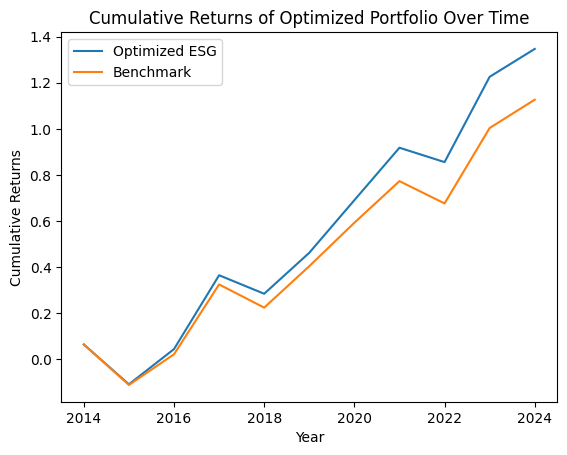

In [53]:
# prompt: can you show the cumulative returns over time for opt_returns

# Calculate cumulative returns for opt_returns
cumulative_opt_returns = (1 + opt_returns).cumprod() - 1
cumulative_bench_returns = (1 + bench_returns).cumprod() - 1

# Create a DataFrame for visualization
cumulative_returns_df = pd.DataFrame({'Year': range(2014, 2025), 'Cumulative returns optimized ESG': cumulative_opt_returns, 'Cumulative returns': cumulative_bench_returns})

# Plot the cumulative returns
plt.plot(cumulative_returns_df['Year'], cumulative_returns_df['Cumulative returns optimized ESG'], label='Optimized ESG')
plt.plot(cumulative_returns_df['Year'], cumulative_returns_df['Cumulative returns'], label='Benchmark')
plt.xlabel('Year')
plt.ylabel('Cumulative Returns')
plt.title('Cumulative Returns of Optimized Portfolio Over Time')
plt.legend()
plt.show()


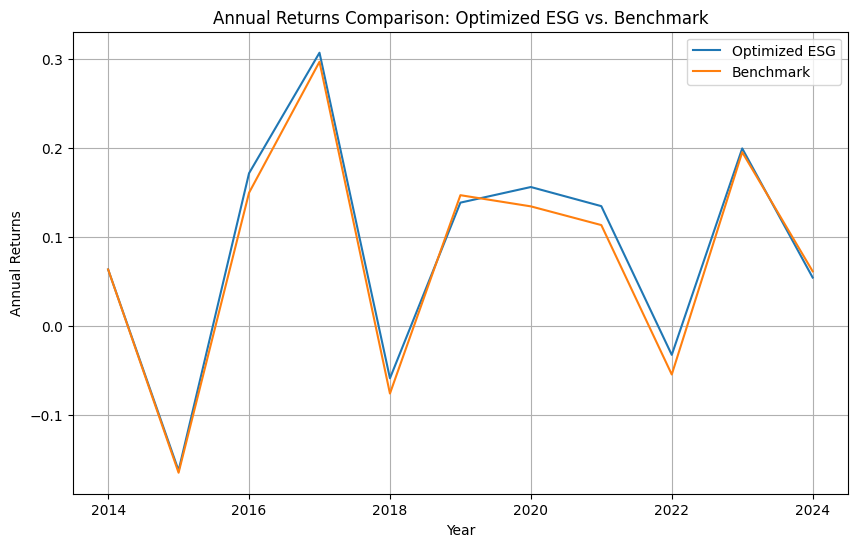

In [54]:
# prompt: creat graph of annual returns opt and bench

# Convert dict values to a list or array
opt_returns = np.array(list(optimized_annual_returns.values()))
bench_returns = np.array(list(benchmark_annual_returns.values()))

# Create a DataFrame for visualization
annual_returns_df = pd.DataFrame({
    'Year': range(2014, 2025),
    'Optimized ESG Returns': opt_returns,
    'Benchmark Returns': bench_returns
})

# Plot the annual returns
plt.figure(figsize=(10, 6))
plt.plot(annual_returns_df['Year'], annual_returns_df['Optimized ESG Returns'], label='Optimized ESG')
plt.plot(annual_returns_df['Year'], annual_returns_df['Benchmark Returns'], label='Benchmark')
plt.xlabel('Year')
plt.ylabel('Annual Returns')
plt.title('Annual Returns Comparison: Optimized ESG vs. Benchmark')
plt.legend()
plt.grid(True)
plt.show()


In [55]:
optimized_monthly_returns = {}
benchmark_monthly_returns = {}

for year, weights_opt in optimized_weights_by_year.items():
    firms = weights_opt.index

    market_caps = market_cap_df[str(year)].loc[firms]
    weights_benchmark = market_caps / market_caps.sum()

    next_year = year + 1
    next_year_mask = returns_df.columns.to_series().dt.year == next_year
    returns_next_year = returns_df.loc[firms, next_year_mask]

    if returns_next_year.empty:
        continue

    monthly_returns_opt = weights_opt @ returns_next_year
    monthly_returns_benchmark = weights_benchmark @ returns_next_year

    # Store monthly returns instead of annual
    optimized_monthly_returns[next_year] = monthly_returns_opt
    benchmark_monthly_returns[next_year] = monthly_returns_benchmark


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine all monthly returns into one time series
opt_returns_series = pd.concat(optimized_monthly_returns.values())
bench_returns_series = pd.concat(benchmark_monthly_returns.values())

# Align the index (make sure it uses datetime if it's not already)
opt_returns_series.index = pd.to_datetime(opt_returns_series.index)
bench_returns_series.index = pd.to_datetime(bench_returns_series.index)


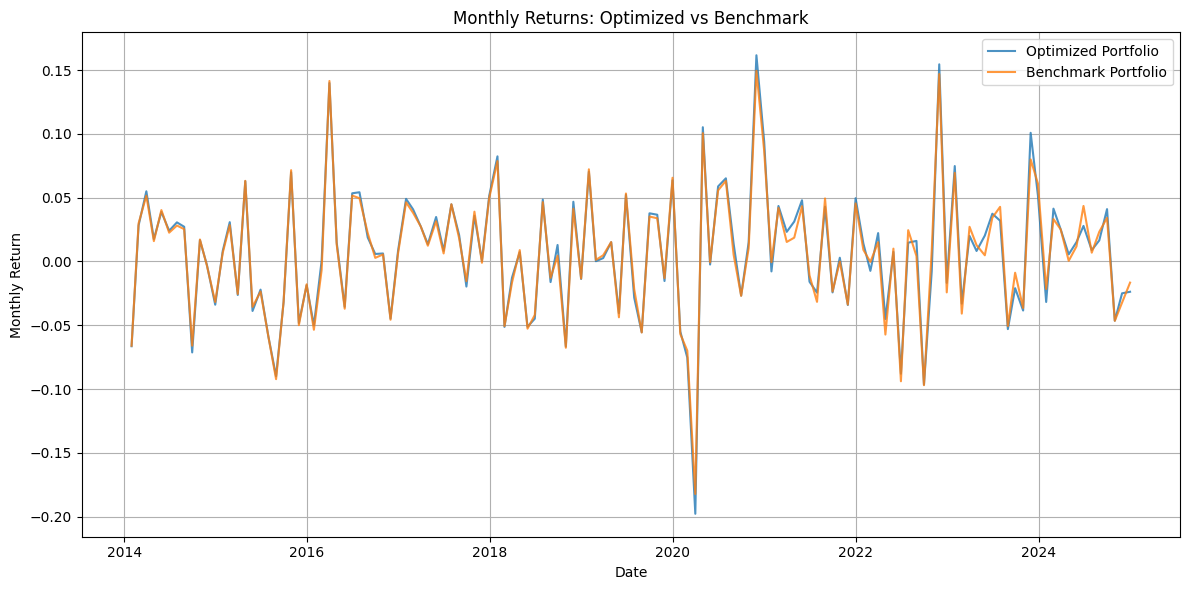

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(opt_returns_series, label='Optimized Portfolio', alpha=0.8)
plt.plot(bench_returns_series, label='Benchmark Portfolio', alpha=0.8)
plt.title('Monthly Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Monthly Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


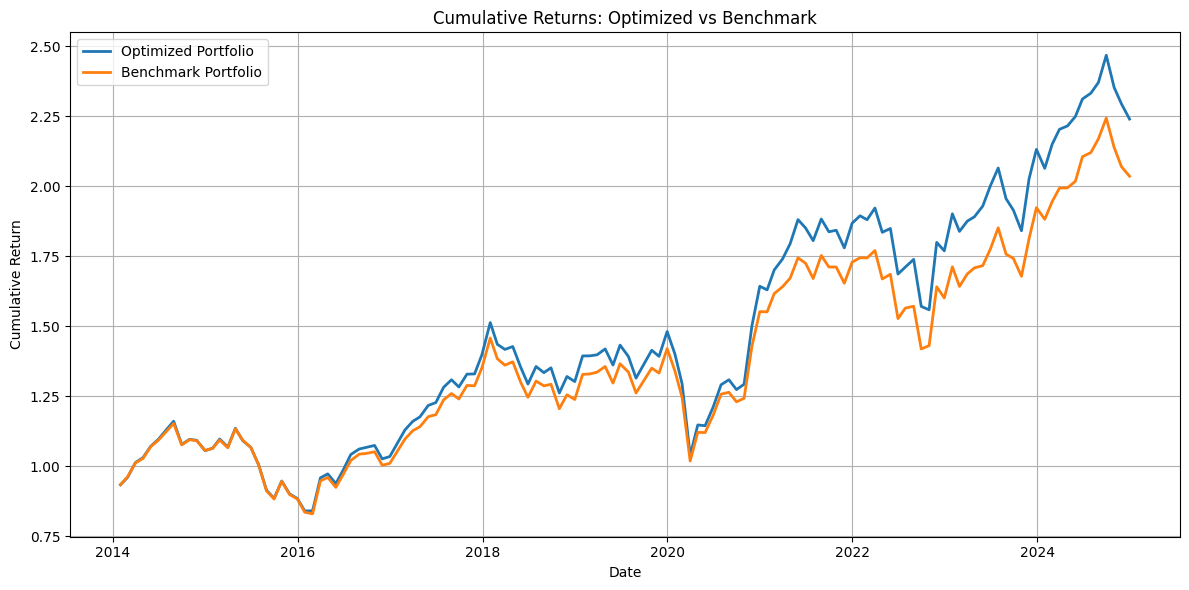

In [58]:
cumulative_opt = (1 + opt_returns_series).cumprod()
cumulative_bench = (1 + bench_returns_series).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_opt, label='Optimized Portfolio', linewidth=2)
plt.plot(cumulative_bench, label='Benchmark Portfolio', linewidth=2)
plt.title('Cumulative Returns: Optimized vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
